In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit





In [2]:
data_dir = Path(r"C:\Users\myles\OneDrive\Desktop\data")

files = sorted(data_dir.glob("phi*_muS*_muR*"))
print("Number of files found:", len(files))
files


Number of files found: 35


[WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.27_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.29_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.31_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.32_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.33_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.34_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.35_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.36_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.37_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.38_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.41_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.42_muS1_muR1.log'),
 WindowsPath('C:/Users/myles/OneDrive/Desktop/data/phi0.43_muS1_muR1.log'),
 WindowsPath

In [3]:


data_dir_rerun = Path(r"C:\Users\myles\OneDrive\Desktop\data_new")  # <-- update folder name
files_rerun = sorted(data_dir_rerun.glob(("run_phi*_mus*_mur*")))
print("Rerun files found:", len(files_rerun))

Rerun files found: 29


In [4]:
def find_table_start(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Time"):
                return i
    raise ValueError(f"No table header found in {path}")

# Find the end of the table by locating the line that begins with "Loop"
def find_table_end(path):
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("Loop"):
                return i
    return None  # If no end marker is found, return None


In [5]:
columns = []
column_names = []

for file in files:
    start = find_table_start(file)
    end = find_table_end(file)

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=start,
        nrows=end - start if end is not None else None,
        on_bad_lines="skip",
        engine="python"
    )

    col = df.iloc[:, 4]  # 5th column

    # Force a unique name based on the filename
    source = Path(file).stem
    new_name = f"{source}_stress_xy"

    col = col.rename(new_name)

    columns.append(col)
    column_names.append(new_name)



columns_rerun = []
for file in files_rerun:
    start = find_table_start(file)
    end = find_table_end(file)
    df = pd.read_csv(file, delim_whitespace=True, skiprows=start,
                     nrows=end - start if end is not None else None,
                     on_bad_lines="skip", engine="python")
    col = df.iloc[:, 4].rename(f"{Path(file).stem}_stress_xy_rerun")
    columns_rerun.append(col)

df_rerun = pd.concat(columns_rerun, axis=1)
df_rerun.insert(0, "Time", range(len(df_rerun)))

eta_f = 0.1; gamma_dot = 0.01
for col in [c for c in df_rerun.columns if c != "Time"]:
    df_rerun[f"reduced_{col}"] = np.abs(df_rerun[col] / (eta_f * gamma_dot))

C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1317191003.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1317191003.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1317191003.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1317191003.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1317191003.py:8: FutureWarning: Th

In [6]:
new_df = pd.concat(columns, axis=1)
new_df.columns = column_names

new_df.insert(0, "Time", range(len(new_df)))

new_df.head()


,Time,phi0.27_muS1_muR1_stress_xy,phi0.29_muS1_muR1_stress_xy,phi0.31_muS1_muR1_stress_xy,phi0.32_muS1_muR1_stress_xy,phi0.33_muS1_muR1_stress_xy,phi0.34_muS1_muR1_stress_xy,phi0.35_muS1_muR1_stress_xy,phi0.36_muS1_muR1_stress_xy,phi0.37_muS1_muR1_stress_xy,...,phi0.5_muS0_muR0_stress_xy,phi0.5_muS1_muR0_stress_xy,phi0.61_muS0_muR0_stress_xy,phi0.62_muS0_muR0_stress_xy,phi0.63_muS0_muR0_stress_xy,phi0.64_muS0_muR0_stress_xy,phi0.6_muS0_muR0_stress_xy,phi0.6_muS1_muR0_stress_xy,phi_0.39_muS1_muR1_stress_xy,phi_0.40_muS1_muR1_stress_xy
0,0,-0.006386,-0.002600,-0.003379,-0.002163,-0.008659,-0.001412,-0.014771,-0.002996,-0.002010,...,-0.023768,-0.023768,-0.083819,-0.069629,-0.140158,-0.179193,-0.037952,-0.037952,-0.005582,-0.006647
1,1,-0.000743,-0.000818,-0.000901,-0.001152,-0.001130,-0.001088,-0.001138,-0.001198,-0.001157,...,-0.002462,-0.002462,-0.009368,-0.013920,-0.023337,-0.030856,-0.006939,-0.006945,-0.001578,-0.001469
2,2,-0.000780,-0.000823,-0.000940,-0.001004,-0.001051,-0.001019,-0.001142,-0.001407,-0.001178,...,-0.002473,-0.002473,-0.009675,-0.014799,-0.026717,-0.033843,-0.007467,-0.007465,-0.001293,-0.001642
3,3,-0.000750,-0.000812,-0.000974,-0.000982,-0.001048,-0.001015,-0.001091,-0.001259,-0.001421,...,-0.002292,-0.002292,-0.010565,-0.016543,-0.034406,-0.038280,-0.007732,-0.007737,-0.001281,-0.001474
4,4,-0.000847,-0.000816,-0.000898,-0.001015,-0.001054,-0.001075,-0.001076,-0.001235,-0.001127,...,-0.002512,-0.002512,-0.011623,-0.018520,-0.046999,-0.044419,-0.008472,-0.008334,-0.001300,-0.001404


In [7]:
eta_f = 0.1      # fluid viscosity
gamma_dot = 0.01 # shear rate

# 1) remove any previously-computed reduced columns (so re-running is safe)
reduced_cols = [c for c in new_df.columns if c.startswith("reduced_")]
if reduced_cols:
    new_df.drop(columns=reduced_cols, inplace=True)

# 2) pick only the raw (non-reduced) columns to process
raw_cols = [c for c in new_df.columns if c != "Time" and not c.startswith("reduced_")]

# 3) compute reduced viscosity
for col in raw_cols:
    new_df[f"reduced_{col}"] = np.abs(new_df[col] / (eta_f * gamma_dot))

new_df.head()


,Time,phi0.27_muS1_muR1_stress_xy,phi0.29_muS1_muR1_stress_xy,phi0.31_muS1_muR1_stress_xy,phi0.32_muS1_muR1_stress_xy,phi0.33_muS1_muR1_stress_xy,phi0.34_muS1_muR1_stress_xy,phi0.35_muS1_muR1_stress_xy,phi0.36_muS1_muR1_stress_xy,phi0.37_muS1_muR1_stress_xy,...,reduced_phi0.5_muS0_muR0_stress_xy,reduced_phi0.5_muS1_muR0_stress_xy,reduced_phi0.61_muS0_muR0_stress_xy,reduced_phi0.62_muS0_muR0_stress_xy,reduced_phi0.63_muS0_muR0_stress_xy,reduced_phi0.64_muS0_muR0_stress_xy,reduced_phi0.6_muS0_muR0_stress_xy,reduced_phi0.6_muS1_muR0_stress_xy,reduced_phi_0.39_muS1_muR1_stress_xy,reduced_phi_0.40_muS1_muR1_stress_xy
0,0,-0.006386,-0.002600,-0.003379,-0.002163,-0.008659,-0.001412,-0.014771,-0.002996,-0.002010,...,23.767663,23.767663,83.818626,69.629412,140.157700,179.193460,37.951737,37.951737,5.582146,6.646822
1,1,-0.000743,-0.000818,-0.000901,-0.001152,-0.001130,-0.001088,-0.001138,-0.001198,-0.001157,...,2.462115,2.462115,9.367559,13.919755,23.337268,30.855869,6.939140,6.944804,1.578213,1.468689
2,2,-0.000780,-0.000823,-0.000940,-0.001004,-0.001051,-0.001019,-0.001142,-0.001407,-0.001178,...,2.473228,2.473228,9.674612,14.798505,26.716855,33.843131,7.467238,7.464797,1.293037,1.641708
3,3,-0.000750,-0.000812,-0.000974,-0.000982,-0.001048,-0.001015,-0.001091,-0.001259,-0.001421,...,2.292238,2.292238,10.565148,16.542887,34.406431,38.279880,7.732155,7.737135,1.281223,1.473863
4,4,-0.000847,-0.000816,-0.000898,-0.001015,-0.001054,-0.001075,-0.001076,-0.001235,-0.001127,...,2.511830,2.511830,11.623468,18.519856,46.999481,44.419030,8.472280,8.333505,1.300444,1.403658


In [8]:
steady_rerun = df_rerun[(df_rerun["Time"] >= 200)]
reduced_cols_rerun = [c for c in df_rerun.columns if c.startswith("reduced_")]

avg_rerun = steady_rerun[reduced_cols_rerun].mean()
sem_rerun = steady_rerun[reduced_cols_rerun].std() / np.sqrt(len(steady_rerun))

fric_1_1_rerun = avg_rerun[avg_rerun.index.str.contains("mus1_mur1")]
sem_1_1_rerun  = sem_rerun[sem_rerun.index.str.contains("mus1_mur1")].values

fric_1_0_rerun = avg_rerun[avg_rerun.index.str.contains("mus1_mur0")]
sem_1_0_rerun  = sem_rerun[sem_rerun.index.str.contains("mus1_mur0")].values

fric_0_0_rerun = avg_rerun[avg_rerun.index.str.contains("mus0_mur0")]
sem_0_0_rerun  = sem_rerun[sem_rerun.index.str.contains("mus0_mur0")].values
# Set packing fractions to match your rerun phi values (update as needed)
x_1_1_rerun = [0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45]   # <-- fill in your rerun phi values
y_1_1_rerun = np.sort(fric_1_1_rerun.values)

x_1_0_rerun = [0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57]   # <-- fill in your rerun phi values
y_1_0_rerun = np.sort(fric_1_0_rerun.values)

x_0_0_rerun = [0.55, 0.56, 0.57, 0.58, 0.59, 0.60, 0.61, 0.62, 0.63, 0.64]   # <-- fill in your rerun phi values
y_0_0_rerun = np.sort(fric_0_0_rerun.values)

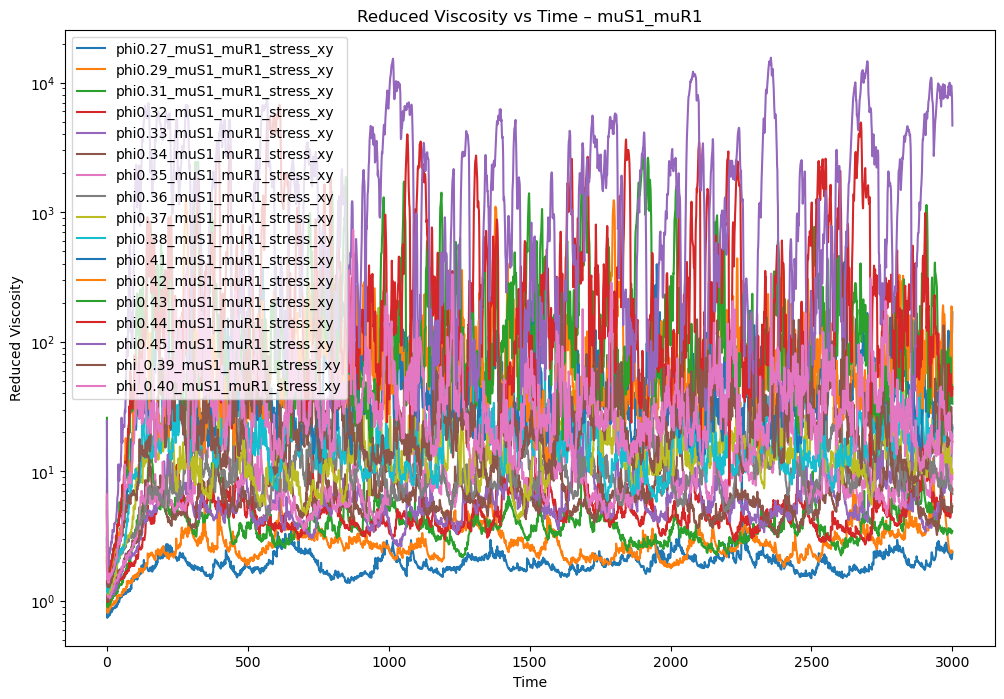

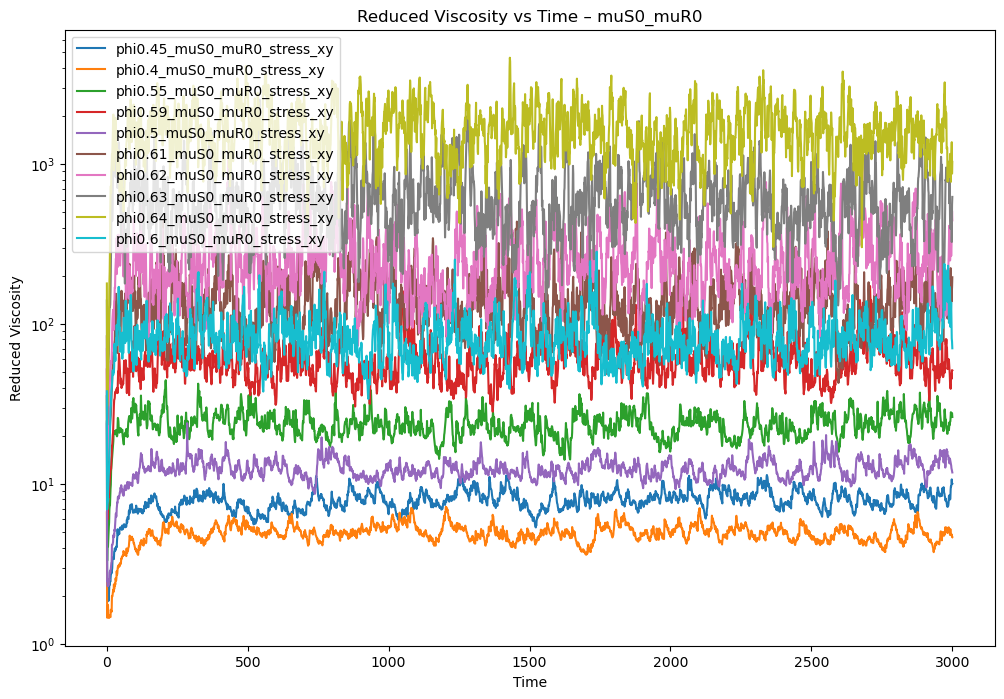

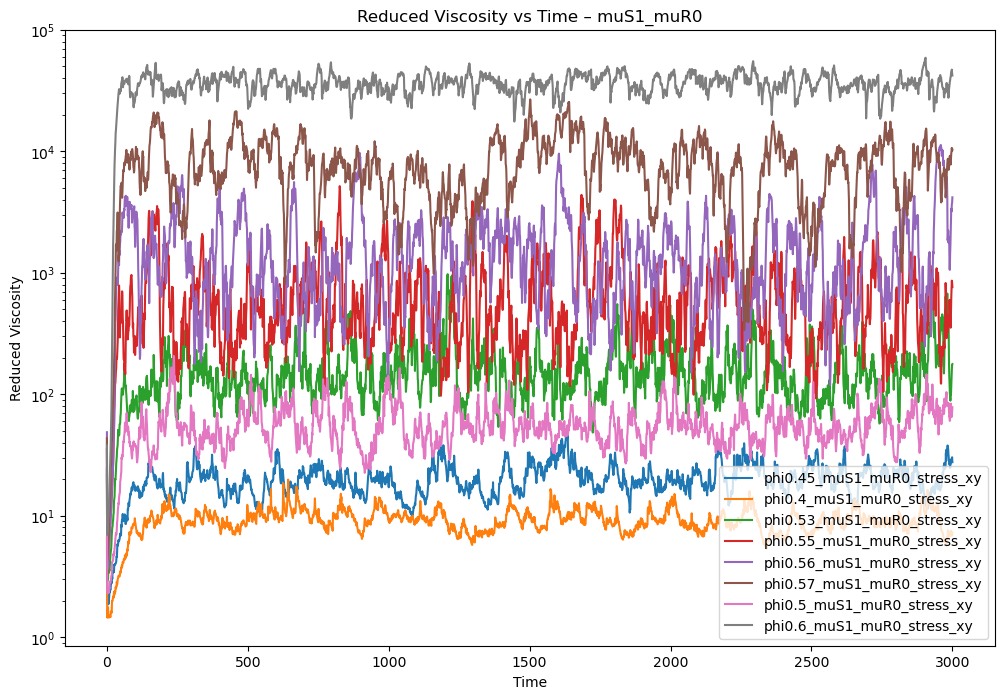

In [9]:
from collections import defaultdict

# build groups of columns by friction combination
combo_groups = defaultdict(list)
for col in new_df.columns:
    if col == "Time" or col.startswith("reduced_"):
        continue
    parts = col.split("_")
    mu_s = next((p for p in parts if p.startswith("muS")), "")
    mu_r = next((p for p in parts if p.startswith("muR")), "")
    combo = f"{mu_s}_{mu_r}"
    combo_groups[combo].append(col)

# loop over groups and plot each on its own figure
for combo, cols in combo_groups.items():
    plt.figure(figsize=(12, 8))
    for col in cols:
        plt.plot(new_df["Time"],
                 np.abs(new_df[col] / (eta_f * gamma_dot)),
                 label=col)
    plt.xlabel("Time")
    plt.yscale("log")
    plt.ylabel("Reduced Viscosity")
    plt.title(f"Reduced Viscosity vs Time – {combo}")
    plt.legend()
    plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
C:\Users\myles\AppData\Local\Temp\ipykernel_13800\1569024916.py:15: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel("Accumulated Strain $\gamma$")


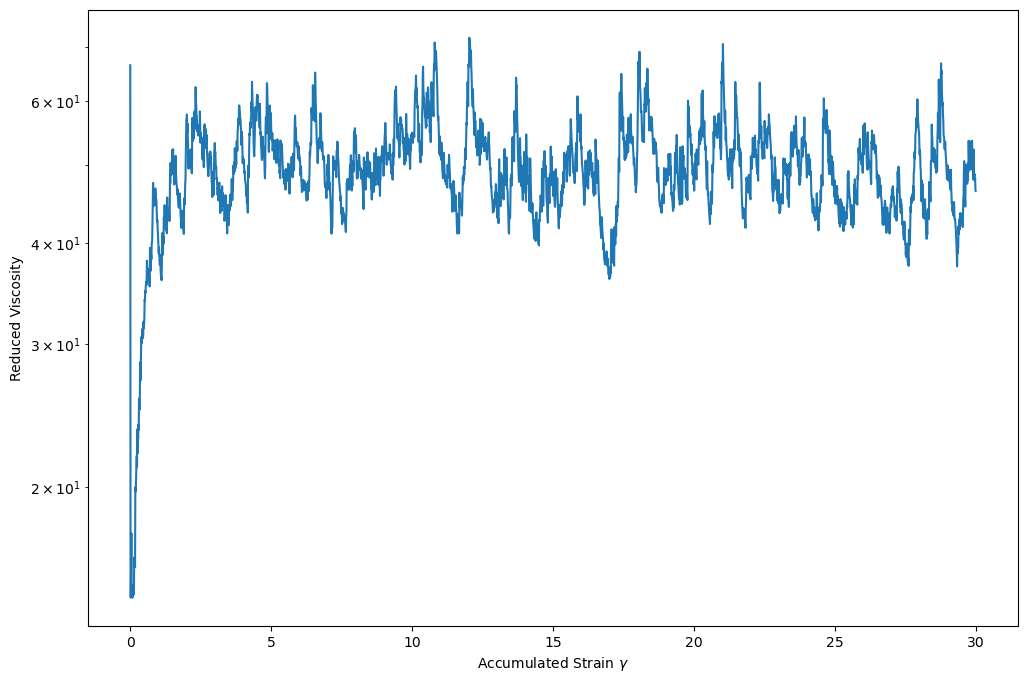

In [10]:
#Plot phi0.4 separatley

y= np.abs(new_df['phi0.4_muS0_muR0_stress_xy']/(0.1*0.001))
ss_y = (new_df['phi0.4_muS0_muR0_stress_xy'][:200])/(0.1*0.001)

mean = np.average(ss_y)

plt.figure(figsize=(12,8))
plt.plot(
    new_df['Time']*0.01,
    y,
    
)
plt.axhline(y=mean)
plt.xlabel("Accumulated Strain $\gamma$")
plt.yscale("log")
plt.ylabel("Reduced Viscosity")
plt.show()

In [11]:
steady_df = new_df[(new_df["Time"] >= 200) & (new_df["Time"] <= 3000)]
reduced_cols = [col for col in new_df.columns if col.startswith("reduced_")]

avg_reduced_stress = steady_df[reduced_cols].mean()
print("Average Reduced Viscosity in Steady State:")
print(avg_reduced_stress)

std_reduced_stress = steady_df[reduced_cols].std()

sem_reduced_stress = std_reduced_stress / 30
print("\nStandard Error of the Mean for Reduced Viscosity in Steady State:")
print(sem_reduced_stress)

# Separate the average reduced viscosity and SEM by friction combo
friction_combos = [("1", "1"), ("1", "0"), ("0.1", "0"), ("0", "0")]
pf = np.array([0.55, 0.5, 0.45, 0.4, 0.35])

fric_1_1 = avg_reduced_stress[avg_reduced_stress.index.str.contains("muS1_muR1")]
print(fric_1_1.values, len(fric_1_1))
fric_1_0 = avg_reduced_stress[avg_reduced_stress.index.str.contains("muS1_muR0")]
print(fric_1_0.values, len(fric_1_0))   
fric_0_0 = avg_reduced_stress[avg_reduced_stress.index.str.contains("muS0_muR0")]
print(fric_0_0.values, len(fric_0_0))



Average Reduced Viscosity in Steady State:
reduced_phi0.27_muS1_muR1_stress_xy         2.011258
reduced_phi0.29_muS1_muR1_stress_xy         2.942303
reduced_phi0.31_muS1_muR1_stress_xy         4.010031
reduced_phi0.32_muS1_muR1_stress_xy         5.207272
reduced_phi0.33_muS1_muR1_stress_xy         6.213239
reduced_phi0.34_muS1_muR1_stress_xy         7.158119
reduced_phi0.35_muS1_muR1_stress_xy        10.236014
reduced_phi0.36_muS1_muR1_stress_xy        11.557918
reduced_phi0.37_muS1_muR1_stress_xy        15.891779
reduced_phi0.38_muS1_muR1_stress_xy        19.496889
reduced_phi0.41_muS1_muR1_stress_xy        53.114568
reduced_phi0.42_muS1_muR1_stress_xy        90.979987
reduced_phi0.43_muS1_muR1_stress_xy       214.724116
reduced_phi0.44_muS1_muR1_stress_xy       553.201914
reduced_phi0.45_muS0_muR0_stress_xy         8.001985
reduced_phi0.45_muS1_muR0_stress_xy        20.516739
reduced_phi0.45_muS1_muR1_stress_xy      2312.679419
reduced_phi0.4_muS0_muR0_stress_xy          5.006113
red


AUTOCORRELATION TIME ANALYSIS SUMMARY

Mean stress (xy component):        0.032266
Standard deviation:                0.681560

Total number of samples:           1000
Autocorrelation time (τ_corr):    2.97
Effective independent samples:     143.9

Correlation factor (2τ+1):         6.95x

--- UNCERTAINTY ESTIMATES ---
Naive SEM (incorrect):             0.021553
Corrected SEM:                     0.056817
Correction factor:                 2.64x

95% Confidence interval:           ±0.111362
Reported as: 0.032266 ± 0.111362



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\home\\claude\\autocorr_analysis.png'

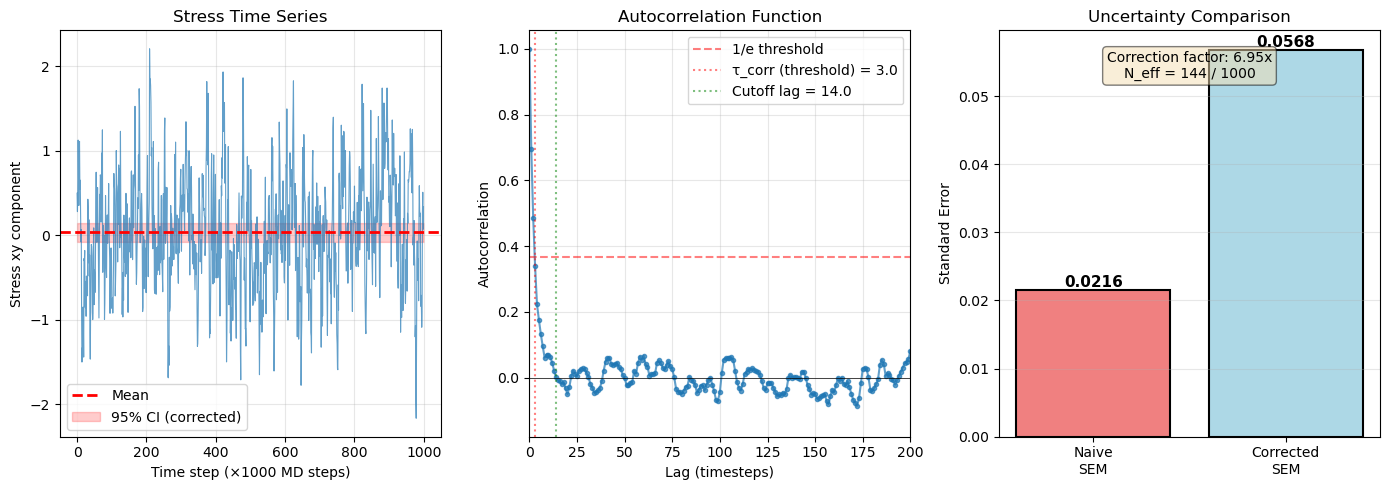

In [12]:

from scipy import signal

def autocorrelation_function(data, max_lag=None):
    """
    Calculate the autocorrelation function (ACF) of a time series.
    
    Parameters:
    -----------
    data : array-like
        Time series data (e.g., stress values)
    max_lag : int, optional
        Maximum lag to compute ACF. If None, uses len(data)//2
    
    Returns:
    --------
    acf : array
        Autocorrelation values from lag 0 to max_lag
    """
    data = np.asarray(data)
    data = data - np.mean(data)  # Center the data
    
    if max_lag is None:
        max_lag = len(data) // 2
    
    # Compute using FFT for efficiency
    c0 = np.dot(data, data) / len(data)
    f = np.fft.fft(data, n=2*len(data))
    acf = np.fft.ifft(f * np.conjugate(f)).real / c0 / len(data)
    
    return acf[:max_lag+1]


def find_autocorr_time(acf, threshold=1/np.e):
    """
    Estimate autocorrelation time using multiple methods.
    
    Parameters:
    -----------
    acf : array
        Autocorrelation function
    threshold : float
        Threshold to find tau_corr (default: 1/e ≈ 0.368)
    
    Returns:
    --------
    tau_corr_integral : float
        Autocorrelation time from integrated ACF (most common)
    tau_corr_threshold : float
        First lag where ACF drops below threshold
    """
    # Method 1: Integrated autocorrelation time (most robust)
    # tau_corr = 0.5 + sum(acf[1:]) until acf becomes negligible
    # Find where ACF becomes noisy (oscillates around zero)
    
    cumsum = np.cumsum(acf)
    # Use first point where ACF crosses zero OR becomes too noisy
    zero_crossings = np.where(np.diff(np.sign(acf[1:])))[0] + 1
    
    if len(zero_crossings) > 0:
        cutoff = zero_crossings[0]
    else:
        cutoff = len(acf) - 1
    
    tau_corr_integral = 0.5 + np.sum(acf[1:cutoff])
    
    # Method 2: Threshold method (simpler, less robust)
    threshold_lags = np.where(acf < threshold)[0]
    if len(threshold_lags) > 0:
        tau_corr_threshold = threshold_lags[0]
    else:
        tau_corr_threshold = len(acf) - 1
    
    return tau_corr_integral, tau_corr_threshold, cutoff


def calculate_corrected_uncertainty(data):
    """
    Calculate mean stress and corrected uncertainty accounting for autocorrelation.
    
    Parameters:
    -----------
    data : array-like
        Time series of stress values
    
    Returns:
    --------
    results : dict
        Dictionary containing:
        - mean: mean stress value
        - std_naive: standard deviation
        - sem_naive: naive SEM (assumes independence)
        - tau_corr: autocorrelation time
        - n_eff: effective number of independent samples
        - sem_corrected: corrected standard error accounting for autocorrelation
        - ci_95: 95% confidence interval half-width
    """
    data = np.asarray(data)
    n_total = len(data)
    
    # Basic statistics
    mean = np.mean(data)
    std = np.std(data, ddof=1)  # sample std
    sem_naive = std / np.sqrt(n_total)
    
    # Calculate autocorrelation
    acf = autocorrelation_function(data, max_lag=n_total//2)
    tau_corr_integral, tau_corr_threshold, cutoff = find_autocorr_time(acf)
    
    # Use integral method (more robust)
    tau_corr = tau_corr_integral
    
    # Effective number of independent samples
    n_eff = n_total / (2 * tau_corr + 1)
    
    # Corrected SEM
    sem_corrected = std / np.sqrt(n_eff)
    
    # 95% confidence interval (assuming normal distribution)
    ci_95 = 1.96 * sem_corrected
    
    results = {
        'mean': mean,
        'std': std,
        'n_total': n_total,
        'sem_naive': sem_naive,
        'tau_corr': tau_corr,
        'tau_corr_threshold': tau_corr_threshold,
        'n_eff': n_eff,
        'sem_corrected': sem_corrected,
        'ci_95': ci_95,
        'correlation_factor': 2 * tau_corr + 1,
        'acf': acf,
        'cutoff_lag': cutoff
    }
    
    return results


def plot_analysis(data, results, figsize=(14, 5)):
    """
    Create diagnostic plots for autocorrelation analysis.
    
    Parameters:
    -----------
    data : array-like
        Time series data
    results : dict
        Results from calculate_corrected_uncertainty()
    figsize : tuple
        Figure size
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Plot 1: Time series with mean
    ax = axes[0]
    ax.plot(data, alpha=0.7, linewidth=0.8)
    ax.axhline(results['mean'], color='r', linestyle='--', linewidth=2, label='Mean')
    ax.fill_between(range(len(data)), 
                     results['mean'] - results['ci_95'],
                     results['mean'] + results['ci_95'],
                     alpha=0.2, color='r', label='95% CI (corrected)')
    ax.set_xlabel('Time step (×1000 MD steps)')
    ax.set_ylabel('Stress xy component')
    ax.set_title('Stress Time Series')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Autocorrelation function
    ax = axes[1]
    acf = results['acf']
    lags = np.arange(len(acf))
    ax.plot(lags, acf, 'o-', alpha=0.7, markersize=3)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
    ax.axhline(1/np.e, color='r', linestyle='--', alpha=0.5, label='1/e threshold')
    ax.axvline(results['tau_corr_threshold'], color='r', linestyle=':', 
               alpha=0.5, label=f'τ_corr (threshold) = {results["tau_corr_threshold"]:.1f}')
    ax.axvline(results['cutoff_lag'], color='g', linestyle=':', 
               alpha=0.5, label=f'Cutoff lag = {results["cutoff_lag"]:.1f}')
    ax.set_xlabel('Lag (timesteps)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('Autocorrelation Function')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, min(200, len(acf)))
    
    # Plot 3: Uncertainty comparison
    ax = axes[2]
    methods = ['Naive\nSEM', 'Corrected\nSEM']
    values = [results['sem_naive'], results['sem_corrected']]
    colors = ['lightcoral', 'lightblue']
    bars = ax.bar(methods, values, color=colors, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Standard Error')
    ax.set_title('Uncertainty Comparison')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add correlation factor as text
    factor = results['correlation_factor']
    ax.text(0.5, 0.95, f'Correction factor: {factor:.2f}x\nN_eff = {results["n_eff"]:.0f} / {results["n_total"]}',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=10)
    
    plt.tight_layout()
    return fig


def print_summary(results):
    """Print a formatted summary of the analysis."""
    print("\n" + "="*70)
    print("AUTOCORRELATION TIME ANALYSIS SUMMARY")
    print("="*70)
    
    print(f"\nMean stress (xy component):        {results['mean']:.6f}")
    print(f"Standard deviation:                {results['std']:.6f}")
    print(f"\nTotal number of samples:           {results['n_total']}")
    print(f"Autocorrelation time (τ_corr):    {results['tau_corr']:.2f}")
    print(f"Effective independent samples:     {results['n_eff']:.1f}")
    print(f"\nCorrelation factor (2τ+1):         {results['correlation_factor']:.2f}x")
    
    print(f"\n--- UNCERTAINTY ESTIMATES ---")
    print(f"Naive SEM (incorrect):             {results['sem_naive']:.6f}")
    print(f"Corrected SEM:                     {results['sem_corrected']:.6f}")
    print(f"Correction factor:                 {results['sem_corrected']/results['sem_naive']:.2f}x")
    
    print(f"\n95% Confidence interval:           ±{results['ci_95']:.6f}")
    print(f"Reported as: {results['mean']:.6f} ± {results['ci_95']:.6f}")
    print("="*70 + "\n")


# Example usage
if __name__ == "__main__":
    # Generate example data (replace with your actual stress data)
    np.random.seed(42)
    t = np.arange(1000)
    # Simulate correlated stress data with AR(1) process
    stress_data = np.zeros(1000)
    stress_data[0] = np.random.normal(0, 1)
    for i in range(1, 1000):
        stress_data[i] = 0.7 * stress_data[i-1] + np.random.normal(0, 0.5)
    
    # Calculate corrected uncertainty
    results = calculate_corrected_uncertainty(stress_data)
    
    # Print summary
    print_summary(results)
    
    # Create plots
    fig = plot_analysis(stress_data, results)
    plt.savefig('/home/claude/autocorr_analysis.png', dpi=150, bbox_inches='tight')
    print("Saved plot to: autocorr_analysis.png")
    plt.show()


FRICTION REGIME: 1_1
Number of conditions (packing fractions): 17
Time points per condition: 2801

FRICTION REGIME: 1_0
Number of conditions (packing fractions): 8
Time points per condition: 2801

FRICTION REGIME: 0_0
Number of conditions (packing fractions): 10
Time points per condition: 2801

SUMMARY TABLE (All Packing Fractions)


Friction 1_1:
ϕ        Mean         ±95% CI      τ_corr     N_eff   
------------------------------------------------------------
0.27_muS1_muR1_stress_xy 2.0113       0.124938     36         38.4    
0.29_muS1_muR1_stress_xy 2.9423       0.309076     41         33.7    
0.31_muS1_muR1_stress_xy 4.0100       0.439181     34         40.6    
0.32_muS1_muR1_stress_xy 5.2073       0.638105     26         52.8    
0.33_muS1_muR1_stress_xy 6.2132       0.730569     27         50.9    
0.34_muS1_muR1_stress_xy 7.1581       0.906251     26         52.8    
0.35_muS1_muR1_stress_xy 10.2360      1.663165     18         75.7    
0.36_muS1_muR1_stress_xy 11.5579    

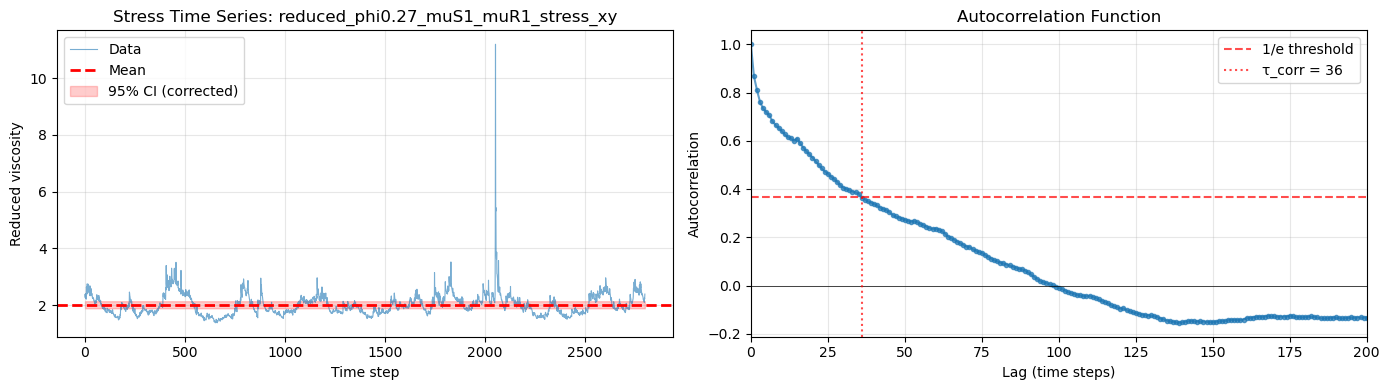

In [13]:
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

# [Your existing code to load and filter data...]
steady_df = new_df[(new_df["Time"] >= 200) & (new_df["Time"] <= 3000)]
reduced_cols = [col for col in new_df.columns if col.startswith("reduced_")]

avg_reduced_stress = steady_df[reduced_cols].mean()
std_reduced_stress = steady_df[reduced_cols].std()

# ============================================================================
# NEW: CORRECTED UNCERTAINTY USING ACF
# ============================================================================

def autocorrelation_function(data, max_lag=None):
    """Calculate ACF efficiently using FFT."""
    data = np.asarray(data)
    data = data - np.mean(data)
    
    if max_lag is None:
        max_lag = len(data) // 3  # Use up to 1/3 of data length
    
    c0 = np.dot(data, data) / len(data)
    f = np.fft.fft(data, n=2*len(data))
    acf = np.fft.ifft(f * np.conjugate(f)).real / c0 / len(data)
    
    return acf[:max_lag+1]


def find_tau_corr(acf, threshold=1/np.e):
    """Find decorrelation timescale."""
    # Method: Find where ACF drops below threshold (1/e ≈ 0.368)
    threshold_lags = np.where(acf < threshold)[0]
    
    if len(threshold_lags) > 0:
        tau_corr = threshold_lags[0]
    else:
        # Fallback: use first zero crossing
        zero_cross = np.where(np.diff(np.sign(acf)))[0]
        if len(zero_cross) > 0:
            tau_corr = zero_cross[0]
        else:
            tau_corr = len(acf) - 1
    
    return tau_corr


def correct_sem_for_autocorr(data_series):
    """
    Calculate SEM corrected for temporal autocorrelation.
    
    Returns:
        sem_naive, sem_corrected, tau_corr, n_eff
    """
    n_total = len(data_series)
    std = data_series.std()
    
    # Naive SEM (assumes independence—WRONG)
    sem_naive = std / np.sqrt(n_total)
    
    # Calculate ACF
    acf = autocorrelation_function(data_series)
    tau_corr = find_tau_corr(acf)
    
    # Effective sample size
    n_eff = n_total / (2 * tau_corr + 1)
    
    # Corrected SEM
    sem_corrected = std / np.sqrt(n_eff)
    
    return sem_naive, sem_corrected, tau_corr, n_eff, acf


# ============================================================================
# APPLY TO EACH FRICTION REGIME
# ============================================================================

friction_combos = {
    "1_1": "muS1_muR1",
    "1_0": "muS1_muR0",
    "0_0": "muS0_muR0"
}

results_corrected = {}

for label, pattern in friction_combos.items():
    print(f"\n{'='*70}")
    print(f"FRICTION REGIME: {label}")
    print(f"{'='*70}")
    
    # Extract data for this friction combo
    cols_for_combo = [col for col in reduced_cols if pattern in col]
    data_for_combo = steady_df[cols_for_combo]
    
    print(f"Number of conditions (packing fractions): {len(cols_for_combo)}")
    print(f"Time points per condition: {len(data_for_combo)}")
    
    results_corrected[label] = {}
    
    # Process each packing fraction
    for col in cols_for_combo:
        data_series = data_for_combo[col].dropna()  # Remove any NaNs
        
        # Calculate means and uncertainty
        mean_visc = data_series.mean()
        sem_naive, sem_corrected, tau_corr, n_eff, acf = correct_sem_for_autocorr(data_series)
        
        # 95% confidence interval
        ci_95 = 1.96 * sem_corrected
        
        # Store results
        results_corrected[label][col] = {
            'mean': mean_visc,
            'std': data_series.std(),
            'sem_naive': sem_naive,
            'sem_corrected': sem_corrected,
            'tau_corr': tau_corr,
            'n_eff': n_eff,
            'ci_95': ci_95,
            'n_total': len(data_series),
            'acf': acf
        }
        
        # Print for one example (e.g., ϕ ≈ 0.50)
        if 'reduced_' in col and '0.50' in col:  # Adjust pattern to match your column names
            print(f"\nExample: {col}")
            print(f"  Mean viscosity:           {mean_visc:.4f}")
            print(f"  Std dev:                  {data_series.std():.4f}")
            print(f"  τ_corr:                   {tau_corr} time steps")
            print(f"  N_eff:                    {n_eff:.1f} (out of {len(data_series)})")
            print(f"  SEM (naive):              {sem_naive:.6f}")
            print(f"  SEM (corrected):          {sem_corrected:.6f}")
            print(f"  Correction factor:        {sem_corrected/sem_naive:.1f}×")
            print(f"  95% CI:                   ±{ci_95:.6f}")

# ============================================================================
# CREATE SUMMARY TABLE
# ============================================================================

print(f"\n{'='*70}")
print("SUMMARY TABLE (All Packing Fractions)")
print(f"{'='*70}\n")

for label in friction_combos.keys():
    print(f"\nFriction {label}:")
    print(f"{'ϕ':<8} {'Mean':<12} {'±95% CI':<12} {'τ_corr':<10} {'N_eff':<8}")
    print("-" * 60)
    
    for col, res in results_corrected[label].items():
        # Extract packing fraction from column name (adjust as needed)
        # Example: if col = "reduced_muS1_muR1_phi0.50", extract 0.50
        phi_str = col.split('phi')[-1] if 'phi' in col else '?'
        
        print(f"{phi_str:<8} {res['mean']:<12.4f} {res['ci_95']:<12.6f} "
              f"{res['tau_corr']:<10.0f} {res['n_eff']:<8.1f}")

# ============================================================================
# DIAGNOSTIC PLOTS (for one example condition)
# ============================================================================

# Pick one friction regime and one packing fraction to visualize
example_label = "1_1"
example_col = [col for col in results_corrected[example_label].keys()][0]
example_data = steady_df[example_col].dropna()
example_results = results_corrected[example_label][example_col]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Time series with uncertainty band
ax = axes[0]
ax.plot(example_data.values, alpha=0.6, linewidth=0.8, label='Data')
ax.axhline(example_results['mean'], color='r', linestyle='--', linewidth=2, label='Mean')
ax.fill_between(range(len(example_data)), 
                 example_results['mean'] - example_results['ci_95'],
                 example_results['mean'] + example_results['ci_95'],
                 alpha=0.2, color='r', label='95% CI (corrected)')
ax.set_xlabel('Time step')
ax.set_ylabel('Reduced viscosity')
ax.set_title(f'Stress Time Series: {example_col}')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Autocorrelation function
ax = axes[1]
acf = example_results['acf']
lags = np.arange(len(acf))
ax.plot(lags, acf, 'o-', alpha=0.7, markersize=3)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(1/np.e, color='r', linestyle='--', alpha=0.7, label=f'1/e threshold')
ax.axvline(example_results['tau_corr'], color='r', linestyle=':', alpha=0.7,
           label=f"τ_corr = {example_results['tau_corr']:.0f}")
ax.set_xlabel('Lag (time steps)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Function')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(200, len(acf)))

plt.tight_layout()
plt.savefig('autocorr_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Saved diagnostic plots to: autocorr_analysis.png")
plt.show()

y_1_1 values: [2.01125814e+00 2.94230334e+00 4.01003075e+00 5.20727202e+00
 6.21323889e+00 7.15811911e+00 1.02360145e+01 1.15579184e+01
 1.58917793e+01 1.94968893e+01 2.69575820e+01 4.34107797e+01
 5.31145679e+01 9.09799865e+01 2.14724116e+02 5.53201914e+02
 2.31267942e+03]
SEM values for fric_1_1: [1.31617052e-02 3.05355235e-02 4.75880772e-02 7.88921010e-02
 8.86663655e-02 1.12044273e-01 2.46101253e-01 1.96311023e-01
 3.91834209e-01 4.07743819e-01 1.54892092e+00 3.79260351e+00
 1.17806484e+01 3.09221884e+01 9.60693606e+01 6.36830721e-01
 1.59144410e+00]
Fitted parameters (xm, A, B): [0.45955965]


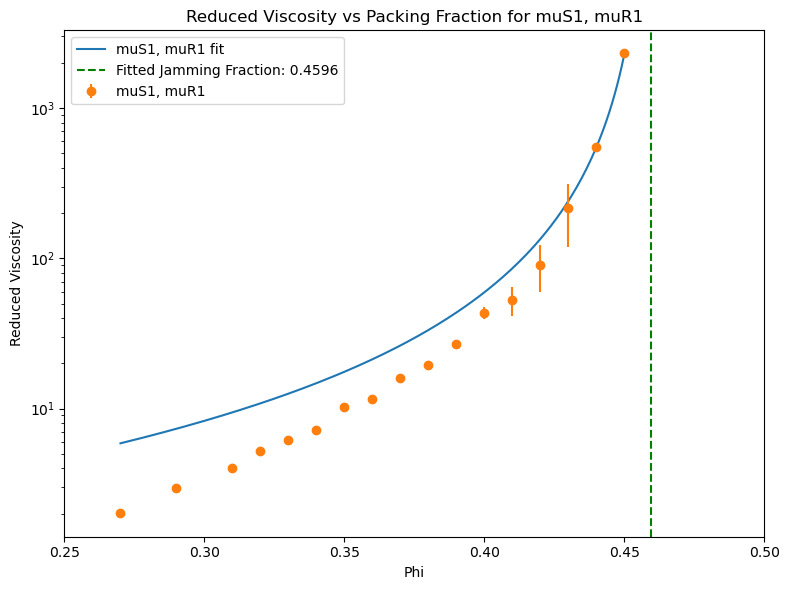

In [ ]:
# Want to plot fric_1_1 values against packibg fraction phi

def func(x, xm, A, B):
    return A *(1-x/xm)**(-B)

def func_fixed(x, xm):
    return (1-x/xm)**(-2)

x_1_1 = [0.27, 0.29, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45]

y_1_1 = np.sort(fric_1_1.values)[:17]
print("y_1_1 values:", y_1_1)

params, _ = curve_fit(func_fixed, x_1_1, y_1_1, p0=[0.4505] , maxfev=10000000)
x_fit = np.linspace(x_1_1[0], x_1_1[-1], 200)
y_fit = func_fixed(x_fit, *params)


# Add error bars to the plot using the SEM values for fric_1_1
sem_1_1 = sem_reduced_stress[sem_reduced_stress.index.str.contains("muS1_muR1")].values[:17]
print("SEM values for fric_1_1:", sem_1_1)
plt.figure(figsize=(8,6))
plt.plot(x_fit, y_fit, label=f'muS{1}, muR{1} fit')
plt.errorbar(x_1_1, y_1_1, yerr=sem_1_1, label='muS1, muR1', marker='o', linestyle='none')
plt.axvline(x=params[0], color='g', linestyle='--', label=f'Fitted Jamming Fraction: {params[0]:.4f}')
plt.xlabel('Phi')
plt.ylabel('Reduced Viscosity')
plt.title('Reduced Viscosity vs Packing Fraction for muS1, muR1')
plt.yscale('log')
plt.xlim(0.25, 0.50)
plt.legend()
plt.grid(False)
plt.tight_layout()

print("Fitted parameters (xm, A, B):", params)

[9.39992825e+00 2.05167392e+01 5.80087105e+01 1.68475349e+02
 6.92317049e+02 1.67467286e+03 8.12754404e+03 3.65098534e+04] 8
[  58.00871054  168.47534874  692.31704884 1674.67286126 8127.54403833]
SEM values for fric_1_0: [  3.47005981  20.10096337  51.97255418 143.20448165   0.72801322]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57638227]


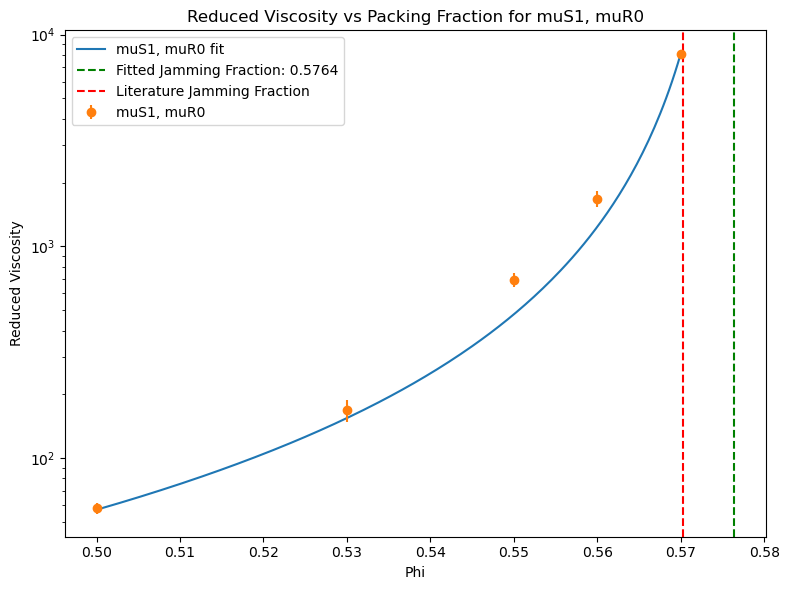

In [ ]:


x_1_0 = [ 0.50 ,0.53, 0.55, 0.56, 0.57]
print(np.sort(fric_1_0.values), len(fric_1_0))

y_1_0 = np.sort(fric_1_0.values)[2:7]
print(y_1_0)



params_1_0, _ = curve_fit(func_fixed, x_1_0, y_1_0, p0=[0.5702], maxfev=10000)
x_fit_1_0 = np.linspace(x_1_0[0], x_1_0[-1], 200)
y_fit_1_0 = func_fixed(x_fit_1_0, *params_1_0)

sem_1_0 = sem_reduced_stress[sem_reduced_stress.index.str.contains("muS1_muR0")].values[2:7]
print("SEM values for fric_1_0:", sem_1_0)

plt.figure(figsize=(8,6))
plt.plot(x_fit_1_0, y_fit_1_0, label=f'muS{1}, muR{0} fit')
plt.errorbar(x_1_0, y_1_0, yerr=sem_1_0, label='muS1, muR0', marker='o', linestyle='none')
plt.axvline(x=params_1_0[0], color='g', linestyle='--', label=f'Fitted Jamming Fraction: {params_1_0[0]:.4f}')
plt.axvline(x= 0.5702, color='r', linestyle='--', label='Literature Jamming Fraction')
plt.yscale('log')
plt.xlabel('Phi')
plt.ylabel('Reduced Viscosity')
plt.title('Reduced Viscosity vs Packing Fraction for muS1, muR0')
plt.legend()
plt.grid(False)
plt.tight_layout()

print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0)



[   5.00611258    8.00198506   12.56729127   23.77701012   60.68551685
   83.14645392  142.28800337  267.74512024  635.97538884 1673.06917845]
y_0_0 values: [  23.77701012   60.68551685   83.14645392  142.28800337  267.74512024
  635.97538884 1673.06917845]
SEM values for fric_0_0: [ 0.60305289  0.05608921  1.93339547  4.36031074 10.18506103 20.45828131
  0.94925838]
Fitted parameters for muS0, muR0 (xm, A, B): [0.65608237]


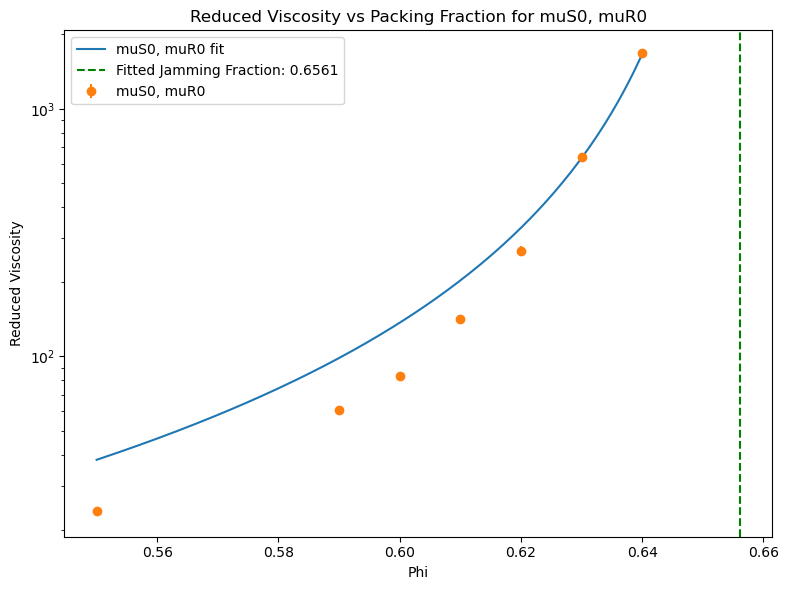

In [ ]:

x_0_0 = [0.55,0.59, 0.60 , 0.61, 0.62, 0.63, 0.64]
print(np.sort(fric_0_0.values))
y_0_0 = np.sort(fric_0_0.values)[3:]
print("y_0_0 values:", y_0_0)



params_0_0, _ = curve_fit(func_fixed, x_0_0, y_0_0, p0=[0.6477], maxfev=100000)
x_fit_0_0 = np.linspace(x_0_0[0], x_0_0[-1], 200)
y_fit_0_0 = func_fixed(x_fit_0_0, *params_0_0)

sem_0_0 = sem_reduced_stress[sem_reduced_stress.index.str.contains("muS0_muR0")].values[3:10]
print("SEM values for fric_0_0:", sem_0_0)

plt.figure(figsize=(8,6))
plt.plot(x_fit_0_0, y_fit_0_0, label=f'muS{0}, muR{0} fit')
plt.errorbar(x_0_0, y_0_0, yerr=sem_0_0, label='muS0, muR0', marker='o', linestyle='none')
plt.axvline(x=params_0_0[0], color='g', linestyle='--', label=f'Fitted Jamming Fraction: {params_0_0[0]:.4f}')
plt.yscale('log')
plt.xlabel('Phi')
plt.ylabel('Reduced Viscosity')
plt.title('Reduced Viscosity vs Packing Fraction for muS0, muR0')
plt.legend()
plt.grid(False)
plt.tight_layout()

print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0)



<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\e'
C:\Users\myles\AppData\Local\Temp\ipykernel_47112\2533871489.py:45: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_47112\2533871489.py:48: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_47112\1447438066.py:7: RuntimeWarning: divide by zero encountered in power
  return (1-x/xm)**(-2)


x length: 11
y length: 11
y values: [  9.16761555  11.90774839  14.84791712  20.31880788  26.53975783
  34.67967212  51.02375919  74.56399642 127.49105794 241.23781403
 604.83021849]
sem length: 11
Column names found: ['reduced_run_phi0.35_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.36_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.37_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.38_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.39_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.40_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.41_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.42_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.43_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.44_mus1_mur1_stress_xy_rerun', 'reduced_run_phi0.45_mus1_mur1_stress_xy_rerun']


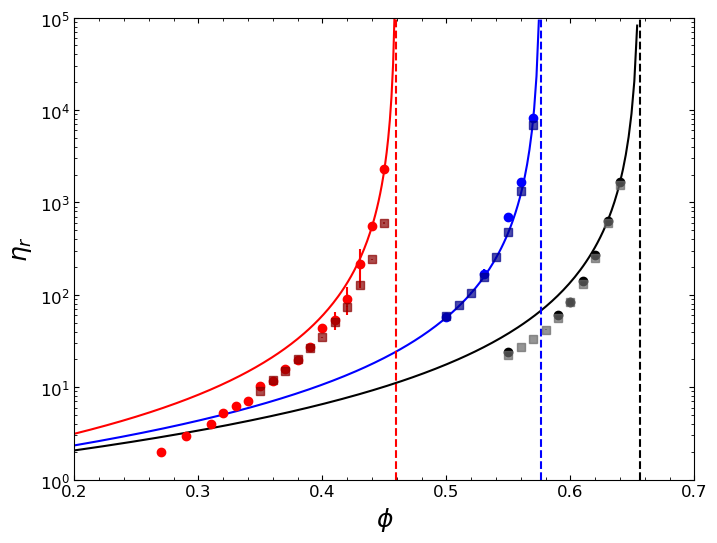

Fitted parameters for muS1, muR1 (xm, A, B): [0.45955965]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57638227]
Fitted parameters for muS0, muR0 (xm, A, B): [0.65608237]


In [ ]:
# Plot the three curves together for comparison, (curves run from 0.20 to their xm value)
plt.figure(figsize=(8,6))

# Recalculate fit curves to extend from 0.20 to jamming fraction
x_fit = np.linspace(0.20, params[0], 200)
y_fit = func_fixed(x_fit, *params)

x_fit_1_0 = np.linspace(0.20, params_1_0[0], 200)
y_fit_1_0 = func_fixed(x_fit_1_0, *params_1_0)

x_fit_0_0 = np.linspace(0.20, params_0_0[0], 200)
y_fit_0_0 = func_fixed(x_fit_0_0, *params_0_0)

# Plot data points
plt.errorbar(x_1_1, y_1_1, yerr=sem_1_1, label='muS1, muR1', marker='o', linestyle='none', color='red')
plt.errorbar(x_1_0, y_1_0, yerr=sem_1_0, label='muS1, muR0', marker='o', linestyle='none', color='blue')
plt.errorbar(x_0_0, y_0_0, yerr=sem_0_0, label='muS0, muR0', marker='o', linestyle='none', color='black')
print("x length:", len(x_1_1_rerun))
print("y length:", len(y_1_1_rerun))
print("y values:", y_1_1_rerun)
print("sem length:", len(sem_1_1_rerun))
print("Column names found:", fric_1_1_rerun.index.tolist())
plt.errorbar(x_1_1_rerun, y_1_1_rerun, yerr=sem_1_1_rerun,
             label='muS1, muR1 (rerun)', marker='s', linestyle='none',
             color='darkred', alpha=0.7)

plt.errorbar(x_1_0_rerun, y_1_0_rerun, yerr=sem_1_0_rerun,
             label='muS1, muR0 (rerun)', marker='s', linestyle='none',
             color='darkblue', alpha=0.7)

plt.errorbar(x_0_0_rerun, y_0_0_rerun, yerr=sem_0_0_rerun,
             label='muS0, muR0 (rerun)', marker='s', linestyle='none',
             color='dimgray', alpha=0.7)

# Plot fit curves
plt.plot(x_fit, y_fit, label=f'muS1, muR1 fit', color='red')
plt.plot(x_fit_1_0, y_fit_1_0, label=f'muS1, muR0 fit', color='blue')
plt.plot(x_fit_0_0, y_fit_0_0, label=f'muS0, muR0 fit', color='black')

# Add jamming fraction lines
plt.axvline(x=params[0], color='red', linestyle='--', label='Fitted Jamming Fraction (muS1, muR1)')
plt.axvline(x=params_1_0[0], color='blue', linestyle='--', label='Fitted Jamming Fraction (muS1, muR0)')
plt.axvline(x=params_0_0[0], color='black', linestyle='--', label='Fitted Jamming Fraction (muS0, muR0)')

plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(1, 1e5)
plt.yscale('log')
plt.xlim(0.20, 0.7)
plt.grid(False)
plt.show()

print ("Fitted parameters for muS1, muR1 (xm, A, B):", params)
print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0)
print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0)





<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\e'
C:\Users\myles\AppData\Local\Temp\ipykernel_63772\430687567.py:39: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_63772\430687567.py:42: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
C:\Users\myles\AppData\Local\Temp\ipykernel_63772\1447438066.py:7: RuntimeWarning: divide by zero encountered in power
  return (1-x/xm)**(-2)


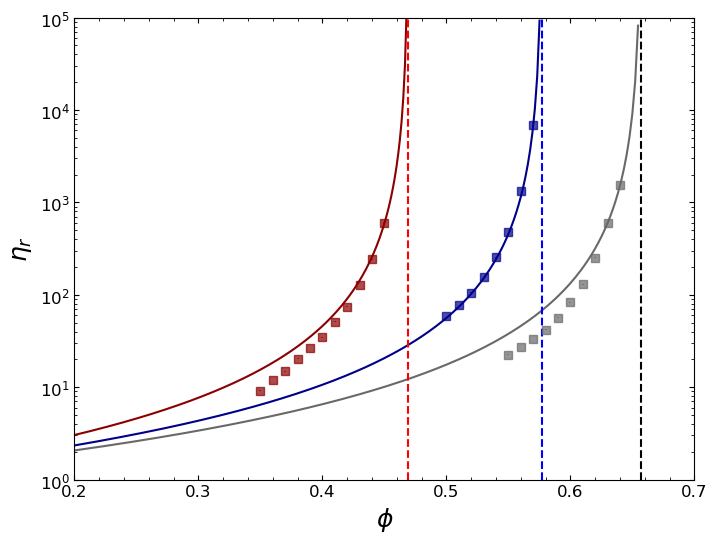

Fitted parameters for muS1, muR1 (xm, A, B): [0.46920924]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57696707]
Fitted parameters for muS0, muR0 (xm, A, B): [0.6567834]


In [ ]:
params_1_1_rerun, _ = curve_fit(func_fixed, x_1_1_rerun, y_1_1_rerun, p0=[0.4505] , maxfev=10000000)
x_1_1_rerun_fit = np.linspace(0.20, params_1_1_rerun[0], 200)
y_1_1_rerun_fit = func_fixed(x_1_1_rerun_fit, *params_1_1_rerun)

params_1_0_rerun, _ = curve_fit(func_fixed, x_1_0_rerun, y_1_0_rerun, p0=[0.5702], maxfev=10000)
x_1_0_rerun_fit = np.linspace(0.20, params_1_0_rerun[0], 200)
y_1_0_rerun_fit = func_fixed(x_1_0_rerun_fit, *params_1_0_rerun)

params_0_0_rerun, _ = curve_fit(func_fixed, x_0_0_rerun, y_0_0_rerun, p0=[0.6477], maxfev=100000)
x_0_0_rerun_fit = np.linspace(0.20, params_0_0_rerun[0], 200)
y_0_0_rerun_fit = func_fixed(x_0_0_rerun_fit, *params_0_0_rerun)

# Plot the three curves together for comparison, (curves run from 0.20 to their xm value)
plt.figure(figsize=(8,6))

plt.errorbar(x_1_1_rerun, y_1_1_rerun, yerr=sem_1_1_rerun,
             label='muS1, muR1 (rerun)', marker='s', linestyle='none',
             color='darkred', alpha=0.7)

plt.errorbar(x_1_0_rerun, y_1_0_rerun, yerr=sem_1_0_rerun,
             label='muS1, muR0 (rerun)', marker='s', linestyle='none',
             color='darkblue', alpha=0.7)

plt.errorbar(x_0_0_rerun, y_0_0_rerun, yerr=sem_0_0_rerun,
             label='muS0, muR0 (rerun)', marker='s', linestyle='none',
             color='dimgray', alpha=0.7)

plt.plot(x_1_1_rerun_fit, y_1_1_rerun_fit, label=f'muS1, muR1 fit', color='darkred')

plt.plot(x_1_0_rerun_fit, y_1_0_rerun_fit, label=f'muS1, muR0 fit', color='darkblue')

plt.plot(x_0_0_rerun_fit, y_0_0_rerun_fit, label=f'muS0, muR0 fit', color='dimgray')

# Add jamming fraction lines
plt.axvline(x=params_1_1_rerun[0], color='red', linestyle='--', label='Fitted Jamming Fraction (muS1, muR1)')
plt.axvline(x=params_1_0_rerun[0], color='blue', linestyle='--', label='Fitted Jamming Fraction (muS1, muR0)')
plt.axvline(x=params_0_0_rerun[0], color='black', linestyle='--', label='Fitted Jamming Fraction (muS0, muR0)')

plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('$\eta_r$', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylim(1, 1e5)
plt.yscale('log')
plt.xlim(0.20, 0.7)
plt.grid(False)
plt.show()

print("Fitted parameters for muS1, muR1 (xm, A, B):", params_1_1_rerun)
print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0_rerun)
print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0_rerun)

In [ ]:
columns_rerun_z = []
column_names_rerun_z = []

for file_rerun in files:
    start = find_table_start(file)
    end = find_table_end(file)

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=start,
        nrows=end - start if end is not None else None,
        on_bad_lines="skip",
        engine="python"
    )

    col_1 = df.iloc[:, 7]  

    # Force a unique name based on the filename
    source = Path(file).stem
    new_name = f"{source}_stress_xy"

    col_1 = col_1.rename(new_name)

    columns_1.append(col_1)
    column_1_names.append(new_name)

In [ ]:
columns_1 = []
column_1_names = []

for file in files:
    start = find_table_start(file)
    end = find_table_end(file)

    df = pd.read_csv(
        file,
        delim_whitespace=True,
        skiprows=start,
        nrows=end - start if end is not None else None,
        on_bad_lines="skip",
        engine="python"
    )

    col_1 = df.iloc[:, 7]  

    # Force a unique name based on the filename
    source = Path(file).stem
    new_name = f"{source}_stress_xy"

    col_1 = col_1.rename(new_name)

    columns_1.append(col_1)
    column_1_names.append(new_name)

    

C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2785744517.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2785744517.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2785744517.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2785744517.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2785744517.py:8: FutureWarning: Th

In [ ]:
contact_df = pd.concat(columns_1, axis=1)
contact_df.columns = column_1_names

contact_df.insert(0, "Time", range(len(contact_df)))

steady_contact_df = contact_df[(contact_df["Time"] >= 200) & (contact_df["Time"] <= 3000)]
reduced_cols = [col for col in steady_contact_df.columns if col.startswith("phi")]
print("Reduced columns:", reduced_cols)

avg_contact = steady_contact_df[reduced_cols].mean()
print("Average Coordinate Number in Steady State:")
print(avg_contact)


std_contact = steady_contact_df[reduced_cols].std()
n = len(steady_contact_df)
sem_contact = std_contact / np.sqrt(n)
#print("\nStandard Error of the Mean for Reduced Viscosity in Steady State:")
#print(sem_reduced_stress)

# Separate the average reduced viscosity and SEM by friction combo
friction_combos = [("1", "1"), ("1", "0"), ("0.1", "0"), ("0", "0")]

fric_1_1 = avg_contact[avg_contact.index.str.contains("muS1_muR1")]
print(fric_1_1.values, len(fric_1_1))
fric_1_0 = avg_contact[avg_contact.index.str.contains("muS1_muR0")]
print(fric_1_0.values, len(fric_1_0))
fric_0_0 = avg_contact[avg_contact.index.str.contains("muS0_muR0")]
print(fric_0_0.values, len(fric_0_0))


Reduced columns: ['phi0.27_muS1_muR1_stress_xy', 'phi0.29_muS1_muR1_stress_xy', 'phi0.31_muS1_muR1_stress_xy', 'phi0.32_muS1_muR1_stress_xy', 'phi0.33_muS1_muR1_stress_xy', 'phi0.34_muS1_muR1_stress_xy', 'phi0.35_muS1_muR1_stress_xy', 'phi0.36_muS1_muR1_stress_xy', 'phi0.37_muS1_muR1_stress_xy', 'phi0.38_muS1_muR1_stress_xy', 'phi0.41_muS1_muR1_stress_xy', 'phi0.42_muS1_muR1_stress_xy', 'phi0.43_muS1_muR1_stress_xy', 'phi0.44_muS1_muR1_stress_xy', 'phi0.45_muS0_muR0_stress_xy', 'phi0.45_muS1_muR0_stress_xy', 'phi0.45_muS1_muR1_stress_xy', 'phi0.4_muS0_muR0_stress_xy', 'phi0.4_muS1_muR0_stress_xy', 'phi0.53_muS1_muR0_stress_xy', 'phi0.55_muS0_muR0_stress_xy', 'phi0.55_muS1_muR0_stress_xy', 'phi0.56_muS1_muR0_stress_xy', 'phi0.57_muS1_muR0_stress_xy', 'phi0.59_muS0_muR0_stress_xy', 'phi0.5_muS0_muR0_stress_xy', 'phi0.5_muS1_muR0_stress_xy', 'phi0.61_muS0_muR0_stress_xy', 'phi0.62_muS0_muR0_stress_xy', 'phi0.63_muS0_muR0_stress_xy', 'phi0.64_muS0_muR0_stress_xy', 'phi0.6_muS0_muR0_stress_

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\2815275531.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$", fontsize=18, fontweight='bold')


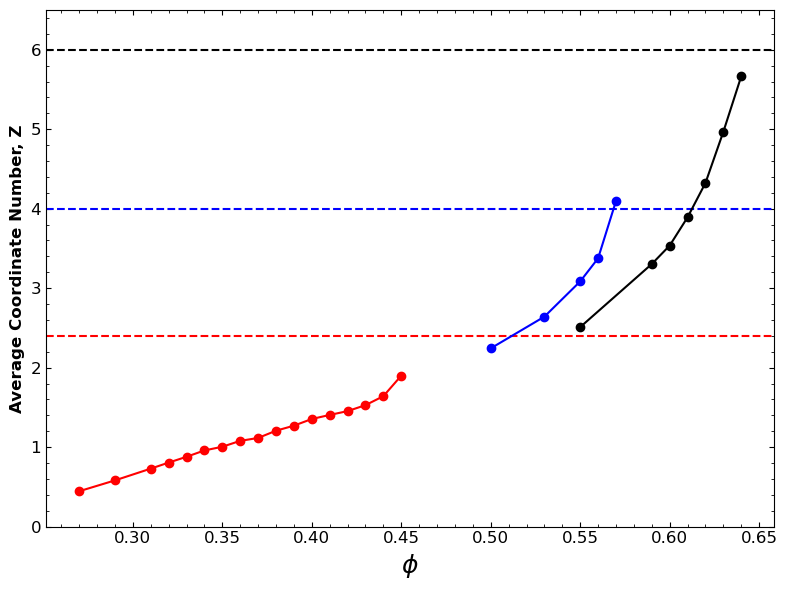

In [ ]:
# Plot the average coordinate number for each packing fraction in steady state for each friction combo

pf_1_1 = [0.27, 0.29, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40, 0.41, 0.42, 0.43, 0.44, 0.45]
pf_1_0 = [ 0.50 ,0.53, 0.55, 0.56, 0.57]
pf_0_0 = [0.55,0.59, 0.60 , 0.61, 0.62, 0.63, 0.64]

plt.figure(figsize=(8,6))
plt.errorbar(pf_1_1, np.sort(fric_1_1.values)[:17], label='muS1, muR1', marker='o', linestyle='-', color='red')
plt.errorbar(pf_1_0, np.sort(fric_1_0.values)[2:7], label='muS1, muR0', marker='o', linestyle='-', color='blue')
plt.errorbar(pf_0_0, np.sort(fric_0_0.values)[3:], label='muS0, muR0', marker='o', linestyle='-', color='black')
plt.axhline(y = 4, color='b', linestyle='--', label='Isostatic Coordinate Number = 4')
plt.axhline(y = 2.4, color='r', linestyle='--', label='Fitted Jamming Coordinate Number = 2.4')
plt.axhline(y = 6, color='black', linestyle='--', label='Maximum Coordinate Number = 6')
plt.ylim(0, 6.5)
plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('Average Coordinate Number, Z', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
plt.xlabel("$\phi$", fontsize=18, fontweight='bold')
plt.minorticks_on()
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.ylabel('Average Coordinate Number, Z', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()


C:\Users\myles\AppData\Local\Temp\ipykernel_20140\1447438066.py:7: RuntimeWarning: divide by zero encountered in power
  return (1-x/xm)**(-2)
C:\Users\myles\AppData\Local\Temp\ipykernel_20140\1624945366.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


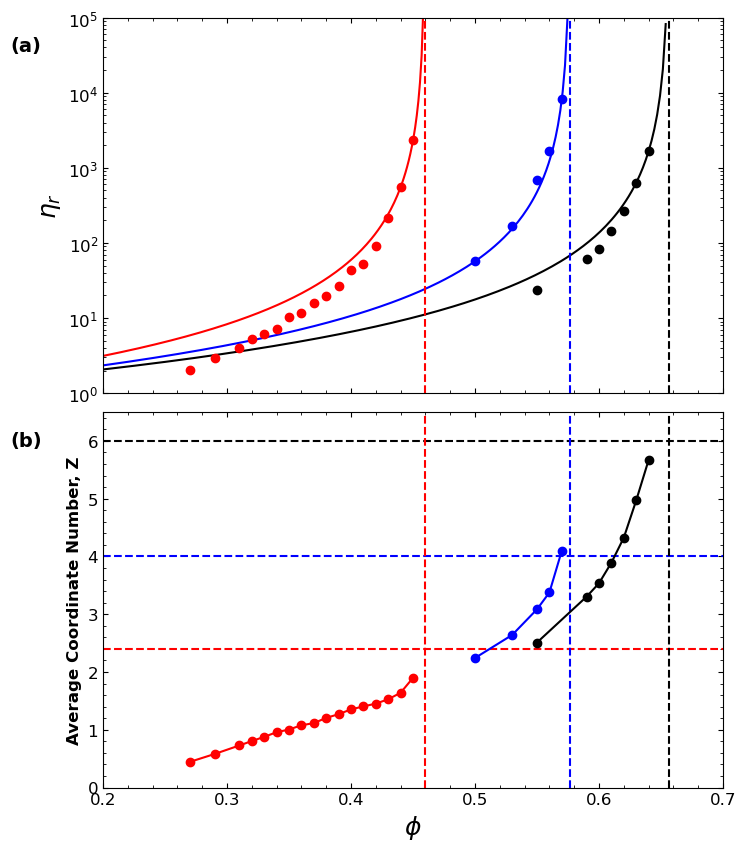

Fitted parameters for muS1, muR1 (xm, A, B): [0.45955965]
Fitted parameters for muS1, muR0 (xm, A, B): [0.57638227]
Fitted parameters for muS0, muR0 (xm, A, B): [0.65608237]


In [ ]:
# --- two stacked subplots, shared x, same width ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    figsize=(8, 10),              # 8 wide, 2x height of your old (8,6)
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1], "hspace": 0.05}
)


# =========================
# TOP: relative viscosity
# =========================
# Recalculate fit curves to extend from 0.20 to jamming fraction
x_fit     = np.linspace(0.20, params[0],      200); y_fit     = func_fixed(x_fit,     *params)
x_fit_1_0 = np.linspace(0.20, params_1_0[0],  200); y_fit_1_0 = func_fixed(x_fit_1_0, *params_1_0)
x_fit_0_0 = np.linspace(0.20, params_0_0[0],  200); y_fit_0_0 = func_fixed(x_fit_0_0, *params_0_0)

# Data points
ax_top.errorbar(x_1_1, y_1_1, label='muS1, muR1', marker='o', linestyle='none', color='red')
ax_top.errorbar(x_1_0, y_1_0, label='muS1, muR0', marker='o', linestyle='none', color='blue')
ax_top.errorbar(x_0_0, y_0_0, label='muS0, muR0', marker='o', linestyle='none', color='black')

# Fit curves
ax_top.plot(x_fit,     y_fit,     label='muS1, muR1 fit', color='red')
ax_top.plot(x_fit_1_0, y_fit_1_0, label='muS1, muR0 fit', color='blue')
ax_top.plot(x_fit_0_0, y_fit_0_0, label='muS0, muR0 fit', color='black')

ax_top.set_ylabel(r'$\eta_r$', fontsize=18, fontweight='bold')
ax_top.set_yscale('log')
ax_top.set_ylim(1, 1e5)
ax_top.set_xlim(0.20, 0.70)

ax_top.minorticks_on()
ax_top.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax_top.grid(False)

# =========================
# BOTTOM: coordination number
# =========================
ax_bot.errorbar(pf_1_1, np.sort(fric_1_1.values)[:17], label='muS1, muR1', marker='o', linestyle='-', color='red')
ax_bot.errorbar(pf_1_0, np.sort(fric_1_0.values)[2:7],  label='muS1, muR0', marker='o', linestyle='-', color='blue')
ax_bot.errorbar(pf_0_0, np.sort(fric_0_0.values)[3:],   label='muS0, muR0', marker='o', linestyle='-', color='black')

ax_bot.axhline(y=4,   color='b',     linestyle='--', label='Isostatic Coordinate Number = 4')
ax_bot.axhline(y=2.4, color='r',     linestyle='--', label='Fitted Jamming Coordinate Number = 2.4')
ax_bot.axhline(y=6,   color='black', linestyle='--', label='Maximum Coordinate Number = 6')

ax_bot.set_xlabel(r'$\phi$', fontsize=18, fontweight='bold')
ax_bot.set_ylabel('Average Coordinate Number, Z', fontsize=12, fontweight='bold')
ax_bot.set_ylim(0, 6.5)

ax_bot.minorticks_on()
ax_bot.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
ax_bot.grid(False)

# =========================
# Vertical dashed lines that continue across BOTH panels
# =========================
jam_lines = [
    (params[0],     'red',   r'Fitted Jamming Fraction (muS1, muR1)'),
    (params_1_0[0], 'blue',  r'Fitted Jamming Fraction (muS1, muR0)'),
    (params_0_0[0], 'black', r'Fitted Jamming Fraction (muS0, muR0)')
]

for xj, c, lab in jam_lines:
    ax_top.axvline(x=xj, color=c, linestyle='--', linewidth=1.5, label=lab)
    ax_bot.axvline(x=xj, color=c, linestyle='--', linewidth=1.5)  # no duplicate label

# Legends (you can move/merge these if you want)

ax_top.text(-0.15, 0.95, '(a)', transform=ax_top.transAxes,
         fontsize=14, fontweight='bold', va='top')

ax_bot.text(-0.15, 0.95, '(b)', transform=ax_bot.transAxes,
         fontsize=14, fontweight='bold', va='top')
plt.tight_layout()
plt.show()

print("Fitted parameters for muS1, muR1 (xm, A, B):", params)
print("Fitted parameters for muS1, muR0 (xm, A, B):", params_1_0)
print("Fitted parameters for muS0, muR0 (xm, A, B):", params_0_0)